OBJETIVO:

ANALIZAR CUALES SON LAS RELACIONES ENTRE LAS VARIABLES QUE TIENEN UNA TIENDA DE COMERCIO ELECTRONICO, VAMOS A GENERAR UNA MATRIZ TERMICA DE CORRELACION PARA QUE NOS AYUDE A ENTENDER MEJOR CUALES SON ESAS RELACIONES.

Analisis Bivariado
     Gasto_publicidad  Clicks_web  Precio  Calificacion  Ventas Totales
0             4370.86      3157.0   96.36           3.3         5308.98
1             9556.43      7761.0  183.14           4.0        11443.13
2             7587.95      6217.0   40.02           2.7        10208.02
3             6387.93      4753.0  108.67           1.5         7404.94
4             2404.17      2856.0   22.04           2.1         3242.84
..                ...         ...     ...           ...             ...
195           4142.89      2611.0  142.24           5.0         5269.77
196           7533.60      5668.0  162.05           3.0        10290.14
197           9073.99      7152.0  109.72           3.4        11394.45
198           8983.78      7342.0   35.65           1.3        12108.63
199           8018.88      7153.0  116.68           4.0        10749.55

[200 rows x 5 columns]

Matriz de correlacion de Pearson
                  Gasto_publicidad  Clicks_web  Precio  Cal

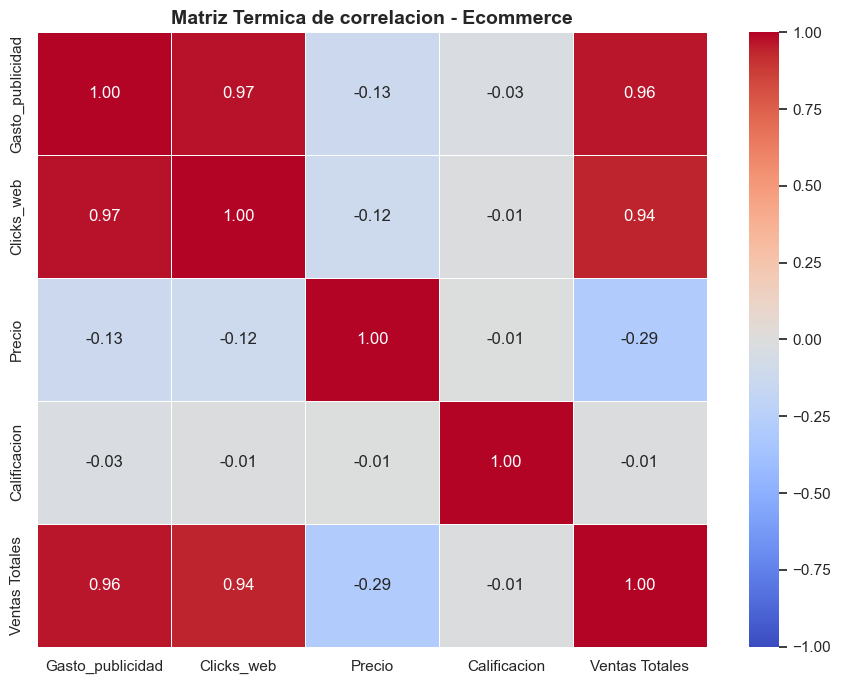

Grafico de dispersion



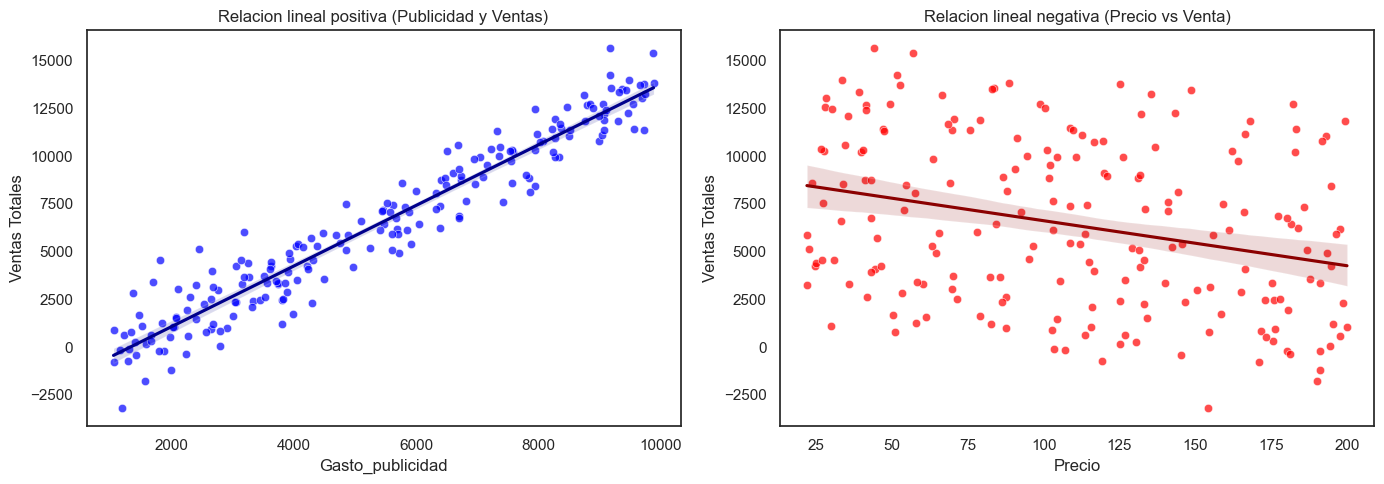

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#std: desviacion estandar

#configuracion de parte visual
sns.set_theme(style="white")
print("Analisis Bivariado")

#crear set de datos
np.random.seed(42)
n_muestras=200
#El uniform nos va a generar numeros con distribucio uniforme ejem: 0 y 1
#1000 - gasto minimo posible que vamos a tener en publicidad 
#10000 - gasto maximo posible, generara 200 muestras
gasto_publicidad=np.random.uniform(1000,10000,n_muestras)
#genera la cantidad de clicks obtenidos segun el gasto de publicidad 
#por cada unidad monetaria que yo invierta yo espero 0.8 clicks le sumamos 0 como media del ruido, una std de 500 y genera los 200 valores
clics_web=gasto_publicidad*0.8+np.random.normal(0,500,n_muestras)
#precio de producto minimo: 20 , maximo 200, genera 200 precios de productos
precio_producto=np.random.uniform(20,200,n_muestras)
# del 1 al 5 estrellas 
calificacion_usuario=np.random.uniform(1,5,n_muestras)
#las ventas simuladas, depende de gasto de publicidad y negativivamente del precio del producto, 
# por cada unidad monetaria ivertidad en publicdad las ventas aumentaran aprox 1.5 unidades
# en el caso del precio del producto al aumentar el precio las ventas totales van a disminuir entonces cada unidad
# adicional en el precio va a reducir la ventas aprox en 15 unidades 
# media 0, std: 1000, genera 200 muestras alaeatorias
ventas_totales=(gasto_publicidad*1.5)-(precio_producto*15)+np.random.normal(0,1000,n_muestras)

df_ecommerce=pd.DataFrame({
    
    'Gasto_publicidad':np.round(gasto_publicidad,2),# redondear a 2 deciamales
    'Clicks_web':np.round(clics_web,0),
    'Precio':np.round(precio_producto,2),
    'Calificacion':np.round(calificacion_usuario,1),
    'Ventas Totales':np.round(ventas_totales,2),
    
})

print(df_ecommerce)
print()

#correlacion de pearson
print("Matriz de correlacion de Pearson")
#corr: 
matriz_correlacion=df_ecommerce.corr(method='pearson')
print(np.round(matriz_correlacion,2))#redondeo de 2

#MAPA DE CALOR
plt.figure(figsize=(9,7))#crea la figura aqui el lienzo
sns.heatmap(
    
    matriz_correlacion,#correlaciones que se representara en el mappa de calor
    annot=True,#escribe el valor numerico dentro de cada una de las celdas
    fmt=".2f", #muestra los valores con 2 decimales
    #utiliza la escala de colores, tonos calidos o rojos representa las correlaciones postivas, 
    # los tonos frios o azules correlaciones negativas, tonos claros correlaciones cercanas a 0
    cmap='coolwarm',
    vmin=-1,#valor minimo de la escala 
    vmax=1,#maxismo
    linewidths=0.5#lineas finitas de espaciado entre la grafica
    
)
plt.title('Matriz Termica de correlacion - Ecommerce',fontsize=14,fontweight='bold')
plt.tight_layout()#espacios entre los graficos
plt.show()

#grafico de dispersion
print("Grafico de dispersion")
print()

#1 GRAFICA
#1 filas con 2 columnas con 14 ancho y de 5 alto
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.scatterplot(
    
    data=df_ecommerce,
    x='Gasto_publicidad',
    y='Ventas Totales',
    ax=axes[0],#1 columna
    color='blue',
    alpha=0.7,#transparencia de 70%

    
)
#RELACION POSITVA: Publicidad ventas
sns.regplot(#agrega linea de regresion sobre el grafico, tomando siempre la misma informacion del dataframe
    
    data=df_ecommerce,
    x='Gasto_publicidad',
    y='Ventas Totales',
    ax=axes[0],
    scatter=False,
    color='darkblue',
    
)
axes[0].set_title('Relacion lineal positiva (Publicidad y Ventas)')
 
#2 GRAFICA
#RELACION NEGATIVA PRECIO vs VENTA
sns.scatterplot(
    
    data=df_ecommerce,
    x='Precio',
    y='Ventas Totales',
    ax=axes[1],#1 columna
    color='red',
    alpha=0.7,#transparencia de 70%

    
)

sns.regplot(
    
    data=df_ecommerce,
    x='Precio',
    y='Ventas Totales',
    ax=axes[1],
    scatter=False,
    color='darkred',
    
)
axes[1].set_title('Relacion lineal negativa (Precio vs Venta)')
plt.tight_layout()
plt.show()


Relacion lineal positiva muy fuerte entre gasto de publicidad y las ventas totales con r=0.96
Las variables gasto_publicidad y clicks_web muestran una asociacion lineal altamente positiva con las ventas_totales. A mayor inversion en publicidad, se incrementa las ventas 

Relacion lineal negativa debil con un r=-0.29
La variable precio presenta una correlacion inversa con las ventas
Precio mas elevados reduce el volumen de las ventas

Las variables predictoras para entrenar el algoritmo de regresion de ventas son: gasto en publicidad y los clicks_Webs